# Monte Carlo Pricing and Implied Volatility

Part 3 of the series. We simulate the stock price process itself, price options by averaging simulated payoffs, then invert the pricing formula to recover volatility from a price using our own Newton-Raphson solver.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [11]:
from optionspricing import black_scholes_call, vega
from optionspricing.monte_carlo import simulate_gbm_paths, monte_carlo_price
from optionspricing.implied_vol import implied_volatility_newton

## Simulating stock prices

Solving the geometric Brownian motion SDE gives

$$ S(t) = S(0)\, e^{(\mu - \sigma^2/2)t + \sigma (X(t) - X(0))} $$

where $(\mu - \sigma^2/2)t$ is the drift (the $\sigma^2/2$ term is Ito's correction) and the second term is Brownian motion. Discretised, it's easier to simulate step by step:

$$ S(t+dt) = S(t)\, e^{(\mu - \sigma^2/2)dt + \sigma\sqrt{dt}\, Z}, \quad Z \sim N(0,1) $$

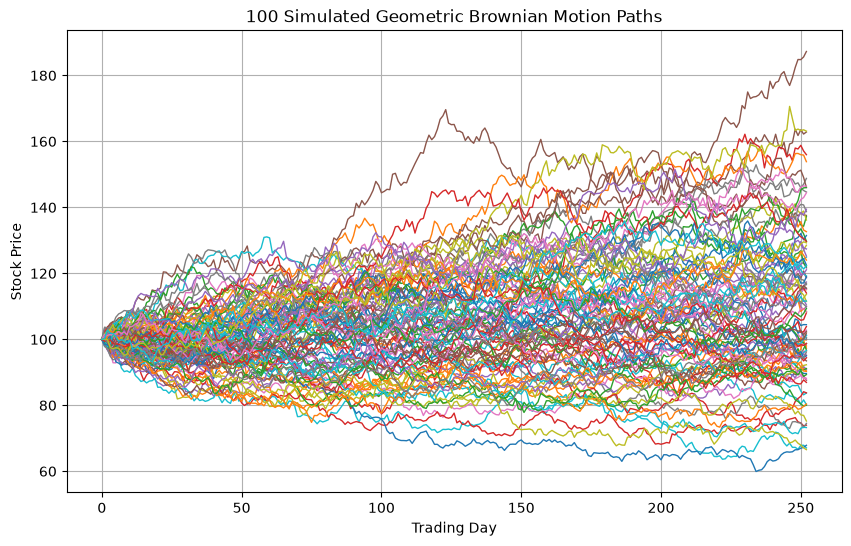

In [12]:
S0, mu, sigma = 100, 0.08, 0.20
T, N = 1, 252  # 1 year, 252 trading days

paths = simulate_gbm_paths(S0, mu, sigma, T, n_steps=N, n_paths=100, rng=np.random.default_rng(0))

plt.figure(figsize=(10, 6))
for path in paths:
    plt.plot(path, linewidth=1)
plt.xlabel('Trading Day'); plt.ylabel('Stock Price')
plt.title('100 Simulated Geometric Brownian Motion Paths')
plt.grid(True); plt.show()

Each path is one possible evolution of the stock price under the same SDE. These simulated paths are the basis of Monte Carlo option pricing below.

## Monte Carlo option pricing

Under the risk-neutral measure we replace the real-world drift $\mu$ with $r$ (options are priced under risk-neutrality, not real-world expectations):

$$ S(T) = S(0)\, e^{(r - \sigma^2/2)T + \sigma\sqrt{T}\, Z} $$

We simulate many terminal prices, compute the payoff for each, and discount the average back to today.

In [13]:
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.20

bs_price = black_scholes_call(S, K, T, r, sigma)
mc_price = monte_carlo_price(S, K, T, r, sigma, n_simulations=100_000, rng=np.random.default_rng(0))

print(f'Black-Scholes Price : {bs_price:.6f}')
print(f'Monte Carlo Price   : {mc_price:.6f}')
print(f'Difference          : {abs(bs_price - mc_price):.6f}')

Black-Scholes Price : 10.450584
Monte Carlo Price   : 10.436163
Difference          : 0.014421


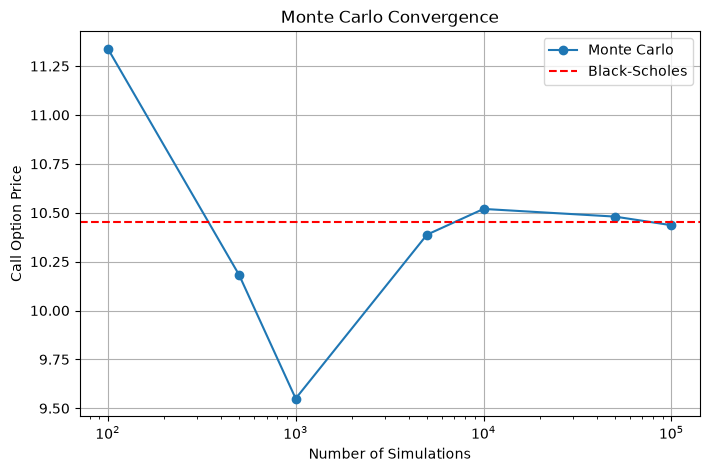

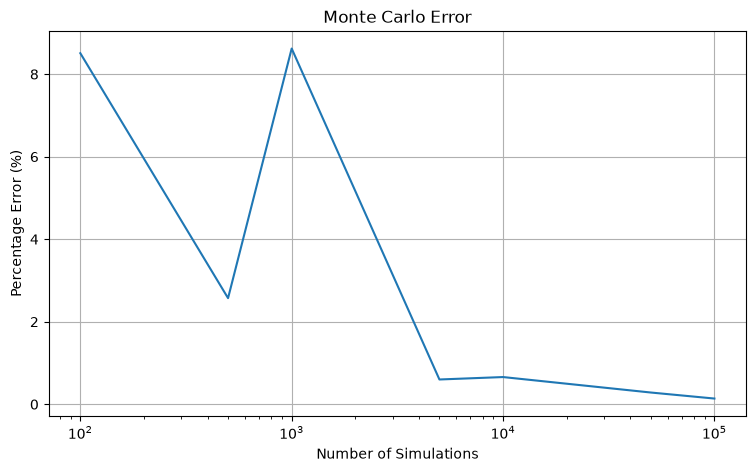

In [14]:
simulation_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = [
    monte_carlo_price(S, K, T, r, sigma, n_simulations=n, rng=np.random.default_rng(0))
    for n in simulation_sizes
]

plt.figure(figsize=(8, 5))
plt.plot(simulation_sizes, mc_prices, marker='o', label='Monte Carlo')
plt.axhline(bs_price, color='red', linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.xlabel('Number of Simulations'); plt.ylabel('Call Option Price')
plt.title('Monte Carlo Convergence'); plt.grid(True); plt.legend(); plt.show()

errors = np.abs(np.array(mc_prices) - bs_price) / bs_price * 100
plt.figure(figsize=(9, 5))
plt.plot(simulation_sizes, errors)
plt.xscale('log')
plt.xlabel('Number of Simulations'); plt.ylabel('Percentage Error (%)')
plt.title('Monte Carlo Error'); plt.grid(True); plt.show()

With few paths the estimate fluctuates noticeably due to sampling error; as the number of paths grows the estimate converges to the analytical Black-Scholes price, by the Law of Large Numbers.

## Implied volatility

Normally we know $\sigma$ and calculate a price $C$. In reality the market quotes a price $C_{market}$, and we solve $BS(\sigma) = C_{market}$ for the unknown volatility. This can't be rearranged algebraically, so we use Newton-Raphson:

$$ f(\sigma) = BS(\sigma) - C_{market}, \qquad \sigma_{n+1} = \sigma_n - f(\sigma_n)/f'(\sigma_n) $$

$f'(\sigma)$ is exactly vega, so no separate derivative code is needed — `implied_volatility_newton` in [`optionspricing.implied_vol`](../src/optionspricing/implied_vol.py) reuses `vega` directly.

In [15]:
market_price = 10.45
iv = implied_volatility_newton(market_price, S, K, T, r)
print(f'Implied Volatility = {iv:.4f} ({100*iv:.2f}%)')

Implied Volatility = 0.2000 (20.00%)


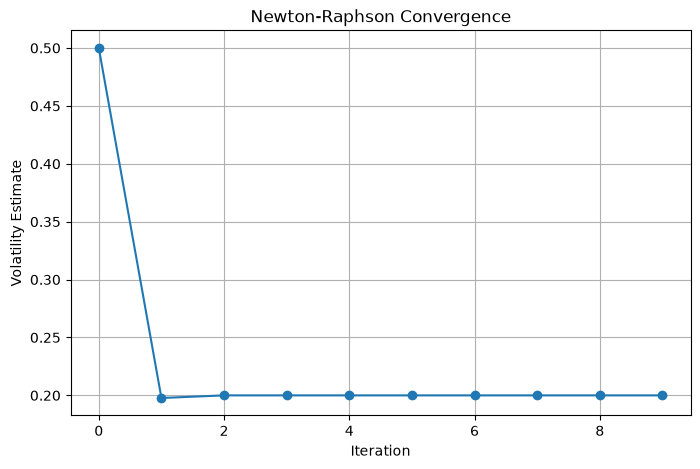

In [16]:
def newton_history(market_price, S, K, T, r, sigma0=0.5, n_iter=10):
    history, s = [], sigma0
    for _ in range(n_iter):
        history.append(s)
        price = black_scholes_call(S, K, T, r, s)
        s = s - (price - market_price) / vega(S, K, T, r, s)
    return history

history = newton_history(market_price, S, K, T, r)

plt.figure(figsize=(8, 5))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteration'); plt.ylabel('Volatility Estimate')
plt.title('Newton-Raphson Convergence'); plt.grid(True); plt.show()

## From a single volatility to a smile and a surface

So far we've solved for a single implied volatility from a single option price. Do that for every strike at one expiry and you get a **volatility smile**; do it across every expiry as well and you get a full **volatility surface** — the market's live map of risk pricing across strike and maturity, instead of the one flat sigma Black-Scholes assumes. Real markets skew towards higher implied vol at low strikes, because they price in more fear of a crash than of an equivalent rally.

[04_real_market_implied_vol.ipynb](04_real_market_implied_vol.ipynb) builds both of these from live option chains, using the exact same `implied_volatility_newton` solver used above.